In [4]:
# Date range filter - just for plotting
START_DATE = '2026-01-26'  # Format: 'YYYY-MM-DD'
END_DATE = '2026-01-30'    # Format: 'YYYY-MM-DD'

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns

# Define file paths for all 4 files
acc_file1 = Path('/Users/xylu/Desktop/Data/machine_local/acc/2026-01-30T17_34_39.363Z.csv')
acc_file2 = Path('/Users/xylu/Desktop/Data/machine_local/acc/2026-01-30T17_38_27.785Z.csv')
belle2_file = Path('/Users/xylu/Desktop/Data/machine_local/belle2/2026-01-30T17_30_53.825Z.csv')
vacuum_file = Path('/Users/xylu/Desktop/Data/machine_local/vacuum/2026-01-30T17_30_05.334Z.csv')

# Read all CSV files with timestamp parsing
acc_df1 = pd.read_csv(acc_file1, parse_dates=['Timestamp'])
acc_df2 = pd.read_csv(acc_file2, parse_dates=['Timestamp'])
belle2_df = pd.read_csv(belle2_file, parse_dates=['Timestamp'])
vacuum_df = pd.read_csv(vacuum_file, parse_dates=['Timestamp'])

print(f"ACC file 1 shape: {acc_df1.shape}")
print(f"ACC file 2 shape: {acc_df2.shape}")
print(f"Belle2 data shape: {belle2_df.shape}")
print(f"Vacuum data shape: {vacuum_df.shape}")
print(f"\nACC file 1 columns ({len(acc_df1.columns)}): {list(acc_df1.columns)}")
print(f"\nACC file 2 columns ({len(acc_df2.columns)}): {list(acc_df2.columns)}")
print(f"\nBelle2 columns ({len(belle2_df.columns)}): {list(belle2_df.columns)}")
print(f"\nVacuum columns ({len(vacuum_df.columns)}): {list(vacuum_df.columns)}")

# Save all numeric columns to variables for correlation analysis
acc1_numeric_cols = acc_df1.select_dtypes(include=[np.number]).columns.tolist()
acc2_numeric_cols = acc_df2.select_dtypes(include=[np.number]).columns.tolist()
belle2_numeric_cols = belle2_df.select_dtypes(include=[np.number]).columns.tolist()
vacuum_numeric_cols = vacuum_df.select_dtypes(include=[np.number]).columns.tolist()

# Combine all data - merge on timestamp with outer join to preserve all data
# First add source column to track origin
acc_df1['source'] = 'ACC1'
acc_df2['source'] = 'ACC2'
belle2_df['source'] = 'Belle2'
vacuum_df['source'] = 'Vacuum'

# Concatenate all dataframes
all_data_list = [acc_df1, acc_df2, belle2_df, vacuum_df]
all_data = pd.concat(all_data_list, axis=0, ignore_index=True, sort=False)

# Save all unique numeric columns (excluding source)
all_numeric_columns = list(set(acc1_numeric_cols + acc2_numeric_cols + belle2_numeric_cols + vacuum_numeric_cols))

# Get min/max dates from all data
all_timestamps = pd.concat([
    acc_df1['Timestamp'],
    acc_df2['Timestamp'],
    belle2_df['Timestamp'],
    vacuum_df['Timestamp']
])

print(f"\n--- Summary ---")
print(f"Total rows combined: {len(all_data)}")
print(f"Total unique numeric columns: {len(all_numeric_columns)}")
print(f"Available data range: {all_timestamps.min()} to {all_timestamps.max()}")
print(f"\nAll numeric columns available for correlation analysis:")
for i, col in enumerate(sorted(all_numeric_columns), 1):
    print(f"  {i:2d}. {col}")

ACC file 1 shape: (6840, 20)
ACC file 2 shape: (4240, 9)
Belle2 data shape: (11101, 10)
Vacuum data shape: (8599, 24)

ACC file 1 columns (20): ['Timestamp', 'B2_nsm:get:ECL_LUM_MON:lum_acc_20', 'CG_OPR:SpecificLuminosity', 'BMLDCCT:CURRENT', 'CGLOPT:IP:BETA_X', 'CGLOPT:IP:BETA_Y', 'CG_OPT:CAP:SIGMAY', 'BTpBPM:QMD11P_K_1:NC_1Hz:C', 'CGLINJ:EFFICIENCY', 'LIiEV:BEAM_REP:READ:KBP', 'CGLINJ:KICKER:HEIGHT_R', 'CGLINJ:KICKER:JUMP_R', 'CGLINJ:SEPTUM:POS_R', 'CGLINJ:SEPTUM:ANG_R', 'LIiRF:MOPS:SET_PHASE:LER', 'CGLINJ:INJECTION:YPOS', 'CGLINJ:INJECTION:YANG', 'BMLD07:INJ:X', 'BMLD07:INJ:Y', 'BMLD07:INJ:Q']

ACC file 2 columns (9): ['Timestamp', 'VALCLM:D06CV1TOP:RQ:SET_POS', 'VALCLM:D06CV1TOP:ST:POS', 'VALCLM:D06CV1BTM:RQ:SET_POS', 'VALCLM:D06CV1BTM:ST:POS', 'BML:MQTAFOP1:POS.PXP', 'BML:MQTAFOP1:POS.PYP', 'BML:MQT3FOP1:POS.PXP', 'BML:MQT3FOP1:POS.PYP']

Belle2 columns (10): ['Timestamp', 'B2_VXD:Rad:Res:BPAtDCU3:A1:DoseRate', 'B2_VXD:Rad:QCS_FW_225:DoseRate', 'B2_VXD:Rad:QCS_FW_135:DoseRate', 'B

In [6]:
# Save each individual column as a separate variable for easy access
# Create a dictionary to store all columns with their data
columns_dict = {}

# Function to create safe variable names from column names
def safe_var_name(col_name, source):
    # Replace special characters with underscores
    safe_name = col_name.replace(':', '_').replace('.', '_').replace('-', '_')
    safe_name = safe_name.replace('(', '').replace(')', '').replace(' ', '_')
    return f"{source}_{safe_name}"

# Store ACC file 1 columns (use 'acc' prefix)
for col in acc1_numeric_cols:
    var_name = safe_var_name(col, 'acc')
    columns_dict[var_name] = acc_df1[col].values
    # Also create the variable in the global namespace
    globals()[var_name] = acc_df1[col].values

# Store ACC file 2 columns (use 'acc' prefix)
for col in acc2_numeric_cols:
    var_name = safe_var_name(col, 'acc')
    columns_dict[var_name] = acc_df2[col].values
    globals()[var_name] = acc_df2[col].values

# Store Belle2 columns
for col in belle2_numeric_cols:
    var_name = safe_var_name(col, 'belle2')
    columns_dict[var_name] = belle2_df[col].values
    globals()[var_name] = belle2_df[col].values

# Store Vacuum columns
for col in vacuum_numeric_cols:
    var_name = safe_var_name(col, 'vacuum')
    columns_dict[var_name] = vacuum_df[col].values
    globals()[var_name] = vacuum_df[col].values

print(f"Created {len(columns_dict)} individual column variables")
print("\nVariable naming convention: [source]_[column_name]")
print("  - source: acc, belle2, vacuum")
print("  - special characters replaced with underscores")
print("\nExample variable names:")
example_vars = list(columns_dict.keys())[:10]
for var in example_vars:
    print(f"  {var}")
print(f"\n... and {len(columns_dict) - 10} more variables")
print("\nAll column variables are also stored in 'columns_dict' dictionary")

Created 59 individual column variables

Variable naming convention: [source]_[column_name]
  - source: acc, belle2, vacuum
  - special characters replaced with underscores

Example variable names:
  acc_B2_nsm_get_ECL_LUM_MON_lum_acc_20
  acc_CG_OPR_SpecificLuminosity
  acc_BMLDCCT_CURRENT
  acc_CGLOPT_IP_BETA_X
  acc_CGLOPT_IP_BETA_Y
  acc_CG_OPT_CAP_SIGMAY
  acc_BTpBPM_QMD11P_K_1_NC_1Hz_C
  acc_CGLINJ_EFFICIENCY
  acc_LIiEV_BEAM_REP_READ_KBP
  acc_CGLINJ_KICKER_HEIGHT_R

... and 49 more variables

All column variables are also stored in 'columns_dict' dictionary


In [7]:
# Display all created variable names organized by source
print("="*80)
print("ALL COLUMN VARIABLES CREATED")
print("="*80)

# ACC variables (both files combined)
print("\n📊 ACC VARIABLES (27 columns from both files):")
print("-"*80)
acc_vars = [k for k in columns_dict.keys() if k.startswith('acc_')]
for i, var in enumerate(sorted(acc_vars), 1):
    print(f"  {i:2d}. {var}")

# Belle2 variables
print("\n📊 BELLE2 VARIABLES (9 columns):")
print("-"*80)
belle2_vars = [k for k in columns_dict.keys() if k.startswith('belle2_')]
for i, var in enumerate(sorted(belle2_vars), 1):
    print(f"  {i:2d}. {var}")

# Vacuum variables
print("\n📊 VACUUM VARIABLES (23 columns):")
print("-"*80)
vacuum_vars = [k for k in columns_dict.keys() if k.startswith('vacuum_')]
for i, var in enumerate(sorted(vacuum_vars), 1):
    print(f"  {i:2d}. {var}")

print("\n" + "="*80)
print(f"TOTAL: {len(columns_dict)} variables created")
print("="*80)

# Print all variable names in a single list
print("\n📋 COMPLETE LIST OF ALL VARIABLE NAMES:")
print("="*80)
all_vars = sorted(columns_dict.keys())
for i, var in enumerate(all_vars, 1):
    print(f"  {i:2d}. {var}")

print("\n" + "="*80)
print("\n💡 TIP: Access any column data using the variable name, e.g.:")
print("   - acc_BMLDCCT_CURRENT")
print("   - belle2_B2_CDC_CUR_AVERAGE")
print("   - vacuum_VALCCG_D04_L01_PRES")

ALL COLUMN VARIABLES CREATED

📊 ACC VARIABLES (27 columns from both files):
--------------------------------------------------------------------------------
   1. acc_B2_nsm_get_ECL_LUM_MON_lum_acc_20
   2. acc_BMLD07_INJ_Q
   3. acc_BMLD07_INJ_X
   4. acc_BMLD07_INJ_Y
   5. acc_BMLDCCT_CURRENT
   6. acc_BML_MQT3FOP1_POS_PXP
   7. acc_BML_MQT3FOP1_POS_PYP
   8. acc_BML_MQTAFOP1_POS_PXP
   9. acc_BML_MQTAFOP1_POS_PYP
  10. acc_BTpBPM_QMD11P_K_1_NC_1Hz_C
  11. acc_CGLINJ_EFFICIENCY
  12. acc_CGLINJ_INJECTION_YANG
  13. acc_CGLINJ_INJECTION_YPOS
  14. acc_CGLINJ_KICKER_HEIGHT_R
  15. acc_CGLINJ_KICKER_JUMP_R
  16. acc_CGLINJ_SEPTUM_ANG_R
  17. acc_CGLINJ_SEPTUM_POS_R
  18. acc_CGLOPT_IP_BETA_X
  19. acc_CGLOPT_IP_BETA_Y
  20. acc_CG_OPR_SpecificLuminosity
  21. acc_CG_OPT_CAP_SIGMAY
  22. acc_LIiEV_BEAM_REP_READ_KBP
  23. acc_LIiRF_MOPS_SET_PHASE_LER
  24. acc_VALCLM_D06CV1BTM_RQ_SET_POS
  25. acc_VALCLM_D06CV1BTM_ST_POS
  26. acc_VALCLM_D06CV1TOP_RQ_SET_POS
  27. acc_VALCLM_D06CV1TOP_ST_

In [8]:
# Create correlation matrix for all numeric columns
# First, let's see how much data we have for each column
print("Data availability for each numeric column:")
for col in all_numeric_columns:
    if col in all_data.columns:
        non_na_count = all_data[col].notna().sum()
        total_count = len(all_data)
        percentage = (non_na_count / total_count) * 100
        print(f"{col}: {non_na_count}/{total_count} ({percentage:.1f}%)")

# Create a subset with only numeric columns for correlation
numeric_data = all_data[all_numeric_columns].copy()

# Calculate correlation matrix (will handle NaN by excluding them pairwise)
correlation_matrix = numeric_data.corr(method='pearson', min_periods=10)

print(f"\nCorrelation matrix shape: {correlation_matrix.shape}")
print(f"Number of valid correlations: {correlation_matrix.notna().sum().sum()}")

Data availability for each numeric column:
VALCCG:D04_L04:PRES: 2019/30780 (6.6%)
CGLINJ:INJECTION:YPOS: 35/30780 (0.1%)
CGLOPT:IP:BETA_Y: 602/30780 (2.0%)
B2_CDC:CUR:LOGGER:L15_2:MAX: 573/30780 (1.9%)
VALCCG:D04_L02:PRES: 2019/30780 (6.6%)
VALCLM:D06CV1BTM:ST:POS: 2019/30780 (6.6%)
VALCCG:D11_L18:PRES: 891/30780 (2.9%)
VALCCG:D10_L06:PRES: 967/30780 (3.1%)
CG_OPR:SpecificLuminosity: 117/30780 (0.4%)
B2_nsm:get:ECL_LUM_MON:lum_acc_20: 126/30780 (0.4%)
CGLINJ:INJECTION:YANG: 35/30780 (0.1%)
CGLINJ:KICKER:HEIGHT_R: 6/30780 (0.0%)
VALCLM:D06CV1BTM:RQ:SET_POS: 18/30780 (0.1%)
BMLD07:INJ:Q: 854/30780 (2.8%)
VALCCG:D10_L03:PRES: 1047/30780 (3.4%)
VALCCG:D10_L02:PRES: 881/30780 (2.9%)
VALCCG:D11_L20:PRES: 2019/30780 (6.6%)
LIiEV:BEAM_REP:READ:KBP: 89/30780 (0.3%)
CGLINJ:SEPTUM:POS_R: 27/30780 (0.1%)
CGLINJ:SEPTUM:ANG_R: 27/30780 (0.1%)
B2_CDC:CUR_AVERAGE: 252/30780 (0.8%)
VALCLM:D06CV1TOP:ST:POS: 2019/30780 (6.6%)
BML:MQTAFOP1:POS.PXP: 2019/30780 (6.6%)
VALCCG:D04_L08:PRES: 1145/30780 (3.7%)


In [9]:
# # Plot all ACC data columns together
# fig, ax = plt.subplots(figsize=(16, 8))

# # Get all numeric columns (exclude Timestamp)
# acc_numeric_cols = acc_df1.select_dtypes(include=[np.number]).columns.tolist()

# # Plot each column
# for col in acc_numeric_cols:
#     ax.plot(acc_df1['Timestamp'], acc_df1[col], label=col, marker='o', markersize=3, alpha=0.7)

# ax.set_xlabel('Time', fontsize=12)
# ax.set_ylabel('Values', fontsize=12)
# ax.set_title('ACC Data - All Columns', fontsize=14, fontweight='bold')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# ax.grid(True, alpha=0.3)
# ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# print(f"Plotted {len(acc_numeric_cols)} columns from ACC data")

# # Plot all Belle2 data columns together
# fig, ax = plt.subplots(figsize=(16, 8))

# # Get all numeric columns (exclude Timestamp)
# belle2_numeric_cols = belle2_df.select_dtypes(include=[np.number]).columns.tolist()

# # Plot each column
# for col in belle2_numeric_cols:
#     ax.plot(belle2_df['Timestamp'], belle2_df[col], label=col, marker='o', markersize=3, alpha=0.7)

# ax.set_xlabel('Time', fontsize=12)
# ax.set_ylabel('Values', fontsize=12)
# ax.set_title('Belle2 Data - All Columns', fontsize=14, fontweight='bold')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# ax.grid(True, alpha=0.3)
# ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# print(f"Plotted {len(belle2_numeric_cols)} columns from Belle2 data")

# # Plot all Vacuum data columns together
# fig, ax = plt.subplots(figsize=(16, 8))

# # Get all numeric columns (exclude Timestamp)
# vacuum_numeric_cols = vacuum_df.select_dtypes(include=[np.number]).columns.tolist()

# # Plot each column
# for col in vacuum_numeric_cols:
#     ax.plot(vacuum_df['Timestamp'], vacuum_df[col], label=col, marker='o', markersize=3, alpha=0.7)

# ax.set_xlabel('Time', fontsize=12)
# ax.set_ylabel('Values', fontsize=12)
# ax.set_title('Vacuum Data - All Columns', fontsize=14, fontweight='bold')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# ax.grid(True, alpha=0.3)
# ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# print(f"Plotted {len(vacuum_numeric_cols)} columns from Vacuum data")

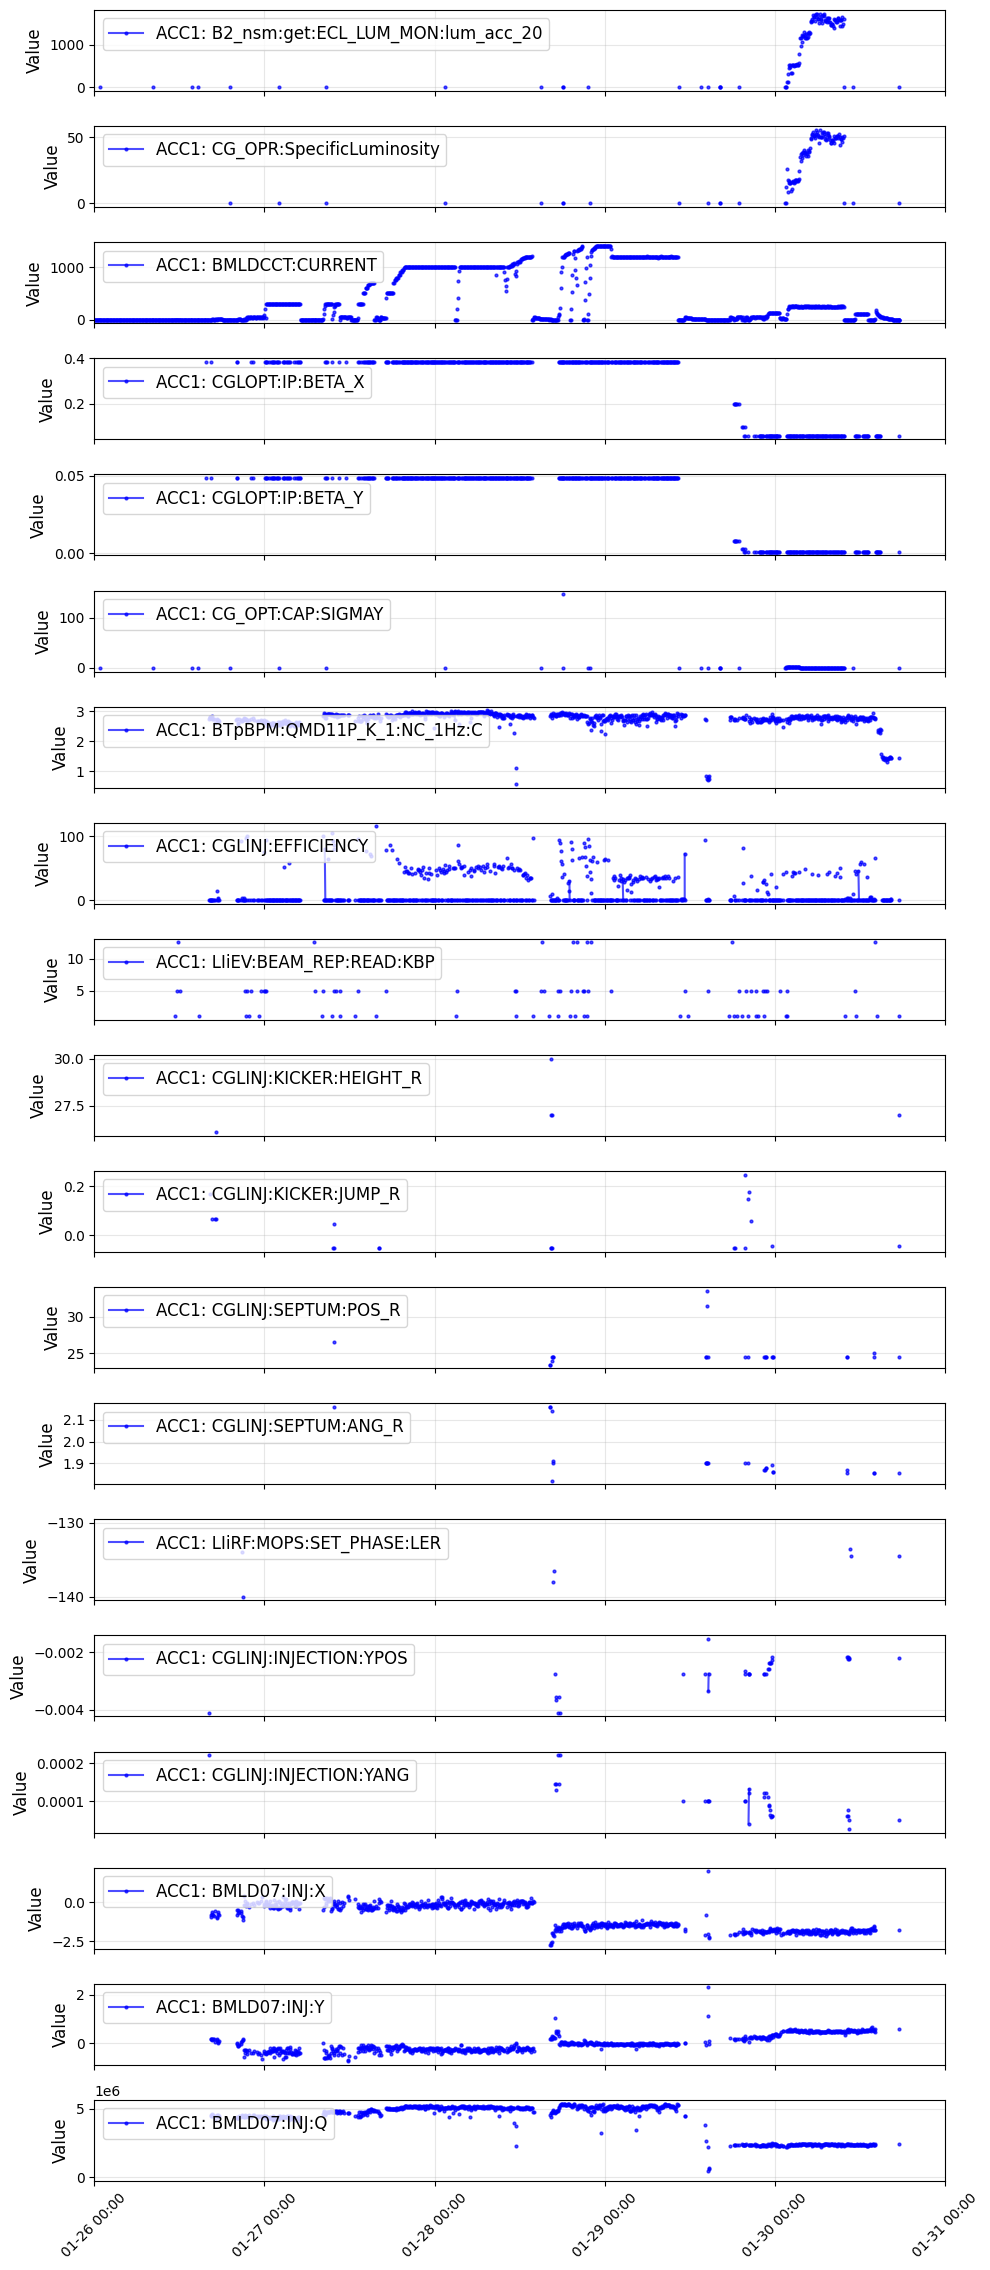

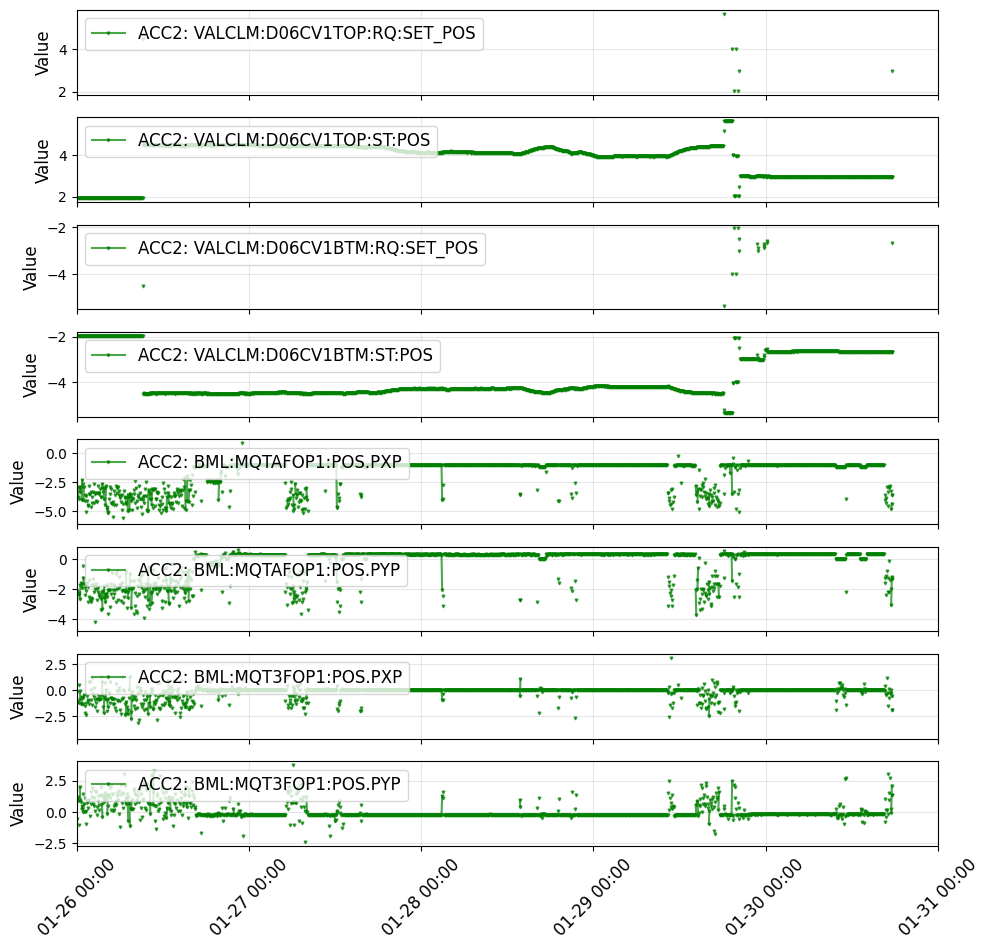

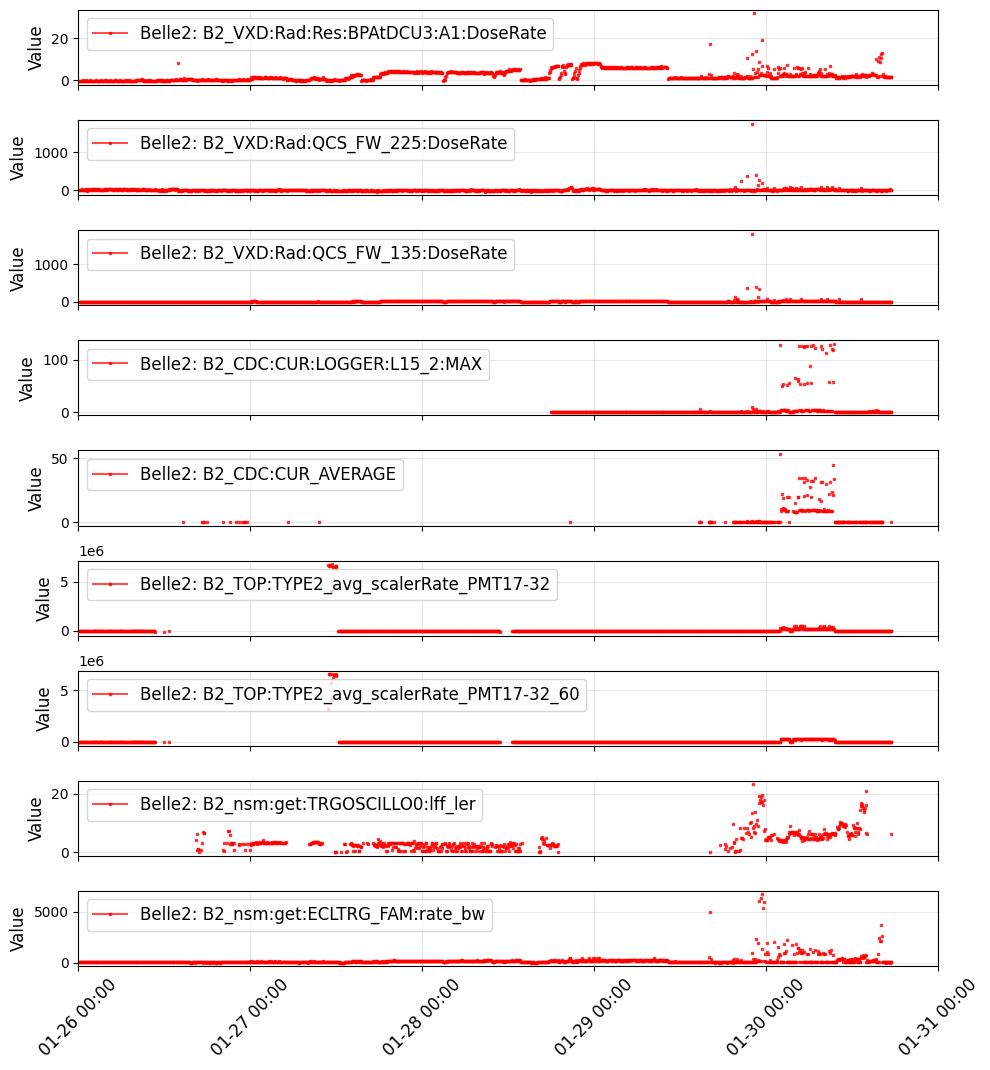

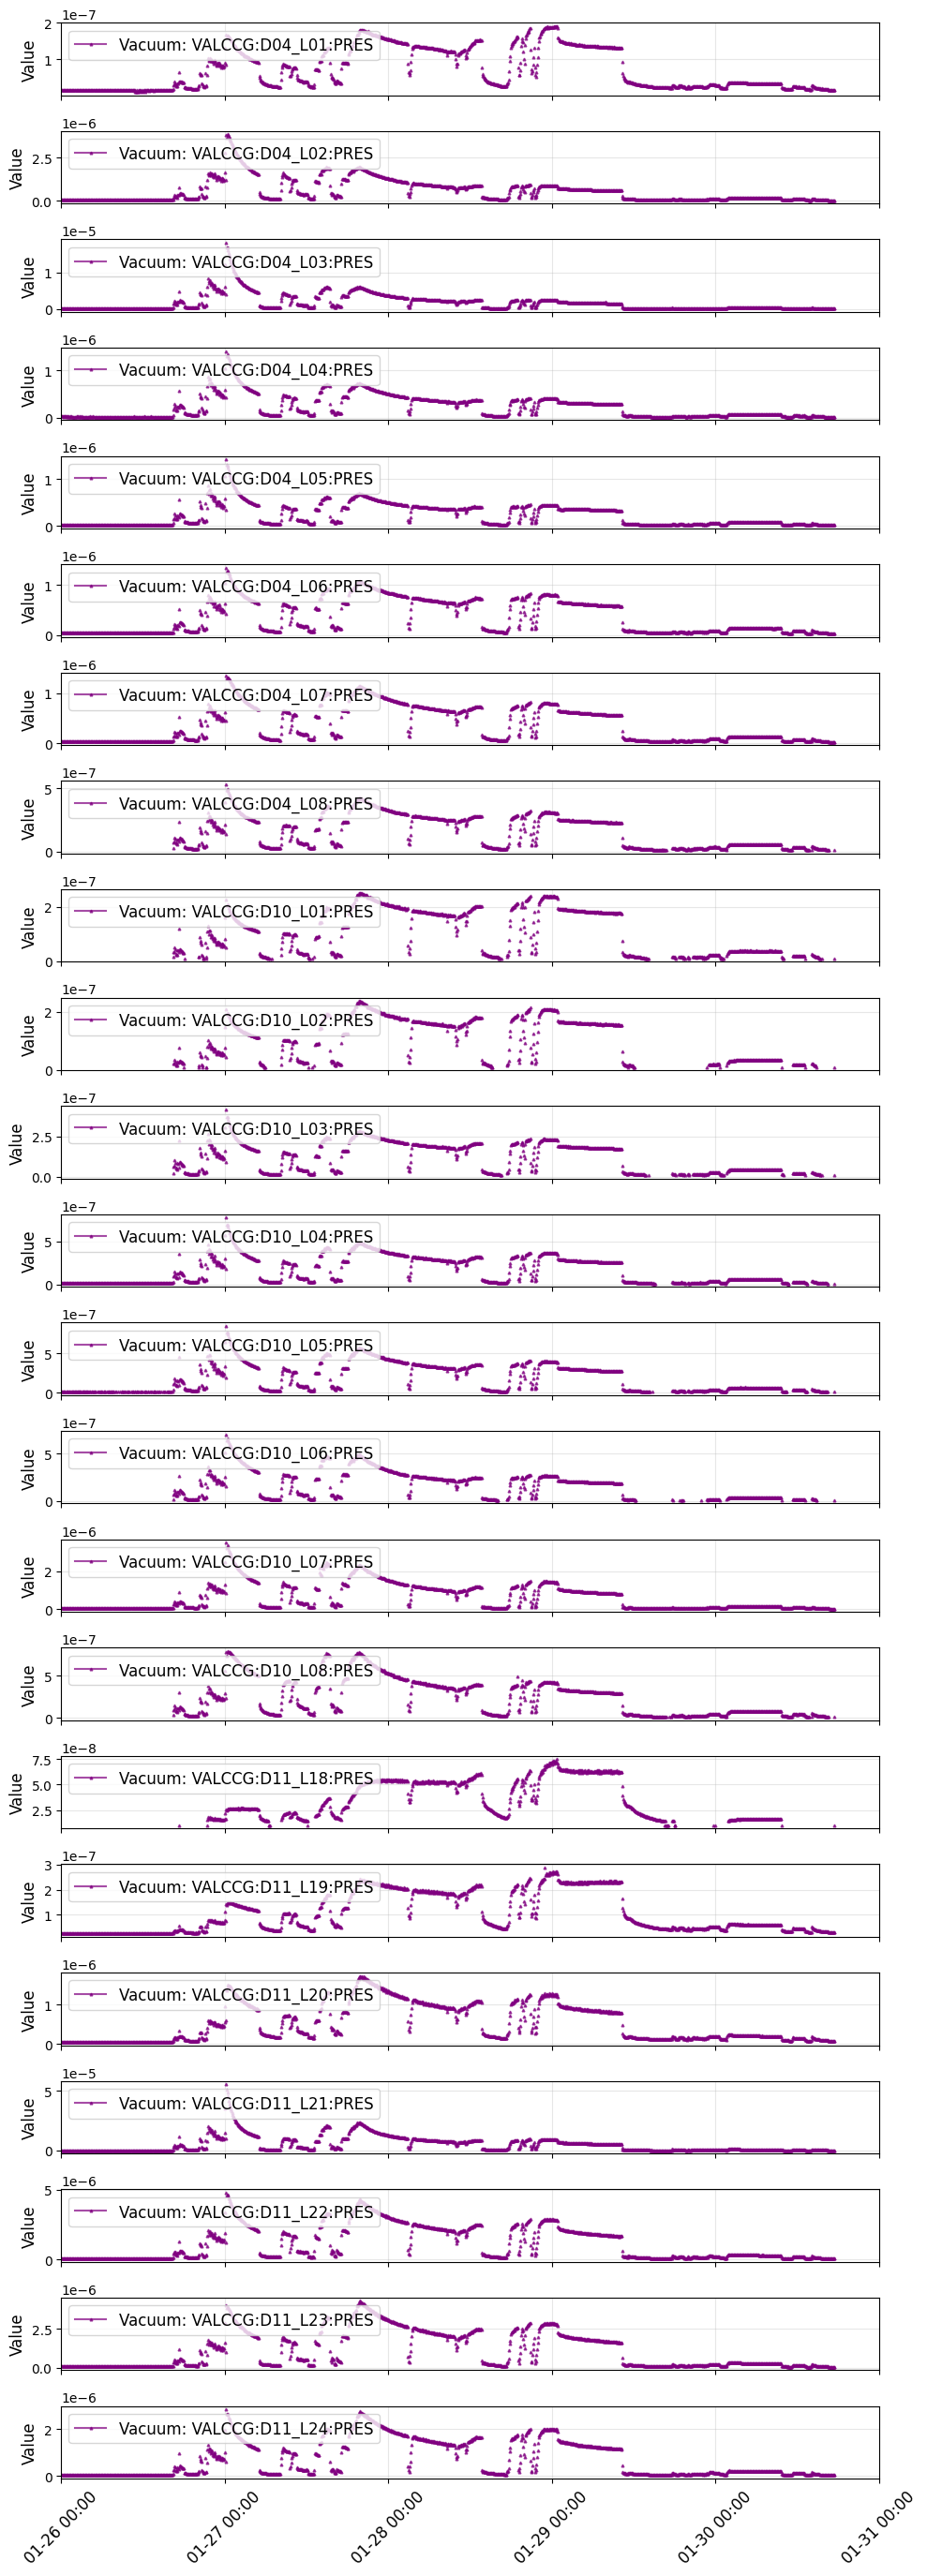

Saved 4 separate figures: acc1_plots.png, acc2_plots.png, belle2_plots.png, vacuum_plots.png


In [10]:
# Create separate figures for each data source with subplots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Figure for ACC1
fig1, axes1 = plt.subplots(len(acc1_numeric_cols), 1, figsize=(10, 1.2*len(acc1_numeric_cols)), sharex=True)
if len(acc1_numeric_cols) == 1:
    axes1 = [axes1]
for i, col in enumerate(acc1_numeric_cols):
    axes1[i].plot(acc_df1['Timestamp'], acc_df1[col], marker='o', markersize=2, alpha=0.7, linestyle='-', color='blue', label=f'ACC1: {col}')
    axes1[i].set_ylabel('Value', fontsize=12)
    axes1[i].legend(loc='upper left', fontsize=12)
    axes1[i].grid(True, alpha=0.3)
    if i < len(acc1_numeric_cols) - 1:
        axes1[i].set_xlabel('')
axes1[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes1:
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
plt.xticks(rotation=45, fontsize=10)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
plt.savefig('acc1_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure for ACC2
fig2, axes2 = plt.subplots(len(acc2_numeric_cols), 1, figsize=(10, 1.2*len(acc2_numeric_cols)), sharex=True)
if len(acc2_numeric_cols) == 1:
    axes2 = [axes2]
for i, col in enumerate(acc2_numeric_cols):
    axes2[i].plot(acc_df2['Timestamp'], acc_df2[col], marker='v', markersize=2, alpha=0.7, linestyle='-', color='green', label=f'ACC2: {col}')
    axes2[i].set_ylabel('Value', fontsize=12)
    axes2[i].legend(loc='upper left', fontsize=12)
    axes2[i].grid(True, alpha=0.3)
    if i < len(acc2_numeric_cols) - 1:
        axes2[i].set_xlabel('')
axes2[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes2:
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
plt.xticks(rotation=45, fontsize=12)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
plt.savefig('acc2_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure for Belle2
fig3, axes3 = plt.subplots(len(belle2_numeric_cols), 1, figsize=(10, 1.2*len(belle2_numeric_cols)), sharex=True)
if len(belle2_numeric_cols) == 1:
    axes3 = [axes3]
for i, col in enumerate(belle2_numeric_cols):
    axes3[i].plot(belle2_df['Timestamp'], belle2_df[col], marker='s', markersize=2, alpha=0.7, linestyle='-', color='red', label=f'Belle2: {col}')
    axes3[i].set_ylabel('Value', fontsize=12)
    axes3[i].legend(loc='upper left', fontsize=12)
    axes3[i].grid(True, alpha=0.3)
    if i < len(belle2_numeric_cols) - 1:
        axes3[i].set_xlabel('')
axes3[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes3:
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
plt.xticks(rotation=45, fontsize=12)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
plt.savefig('belle2_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure for Vacuum
fig4, axes4 = plt.subplots(len(vacuum_numeric_cols), 1, figsize=(10, 1.2*len(vacuum_numeric_cols)), sharex=True)
if len(vacuum_numeric_cols) == 1:
    axes4 = [axes4]
for i, col in enumerate(vacuum_numeric_cols):
    axes4[i].plot(vacuum_df['Timestamp'], vacuum_df[col], marker='^', markersize=2, alpha=0.7, linestyle='-', color='purple', label=f'Vacuum: {col}')
    axes4[i].set_ylabel('Value', fontsize=12)
    axes4[i].legend(loc='upper left', fontsize=12)
    axes4[i].grid(True, alpha=0.3)
    if i < len(vacuum_numeric_cols) - 1:
        axes4[i].set_xlabel('')
axes4[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes4:
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
plt.xticks(rotation=45, fontsize=12)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
plt.savefig('vacuum_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved 4 separate figures: acc1_plots.png, acc2_plots.png, belle2_plots.png, vacuum_plots.png")

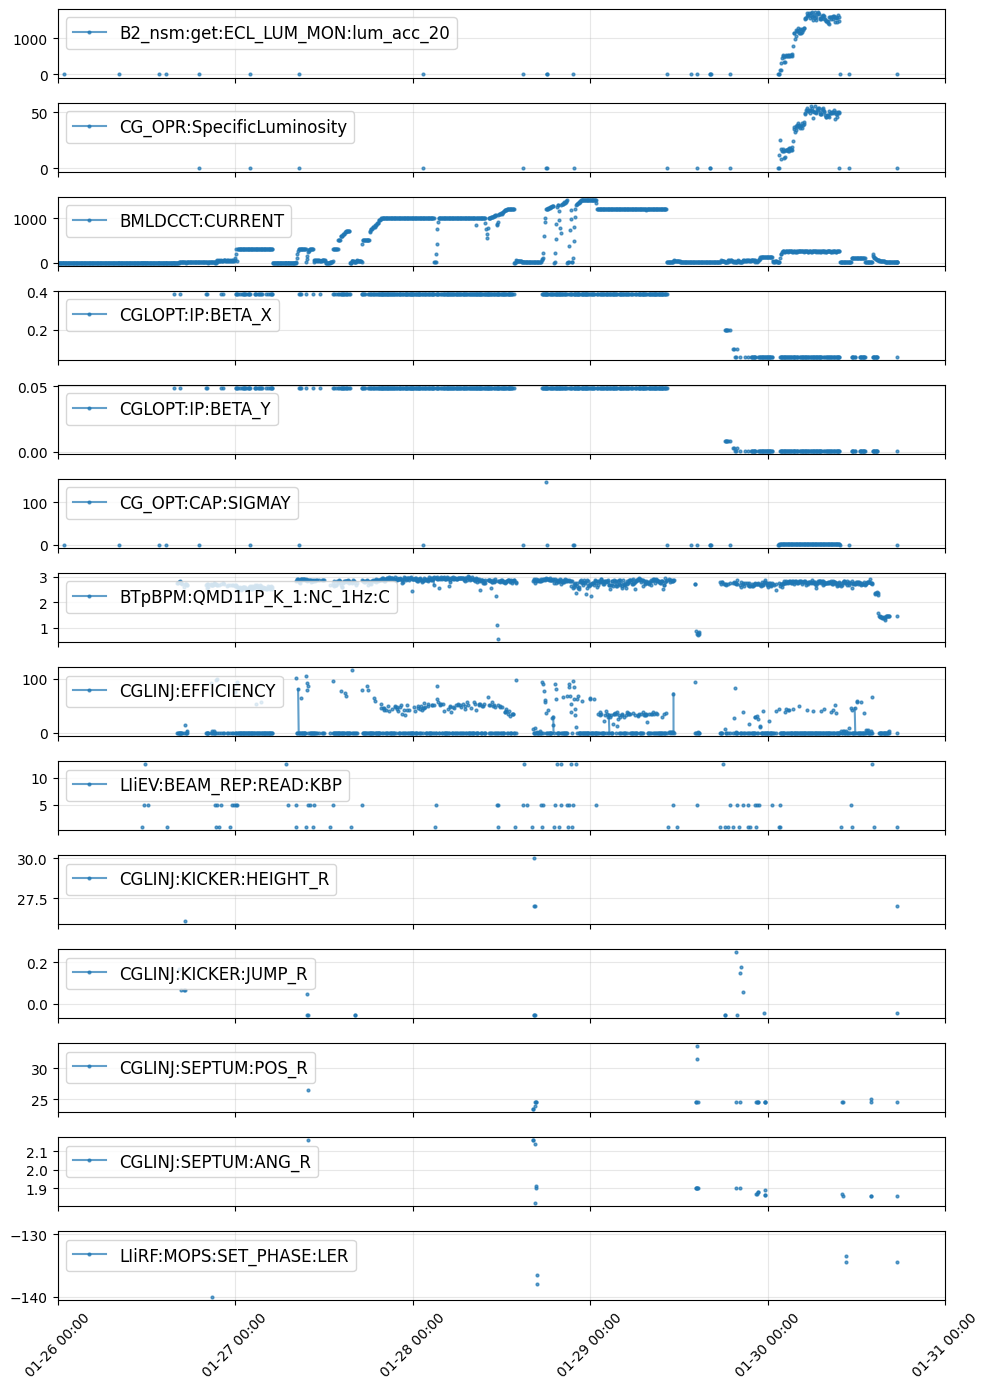

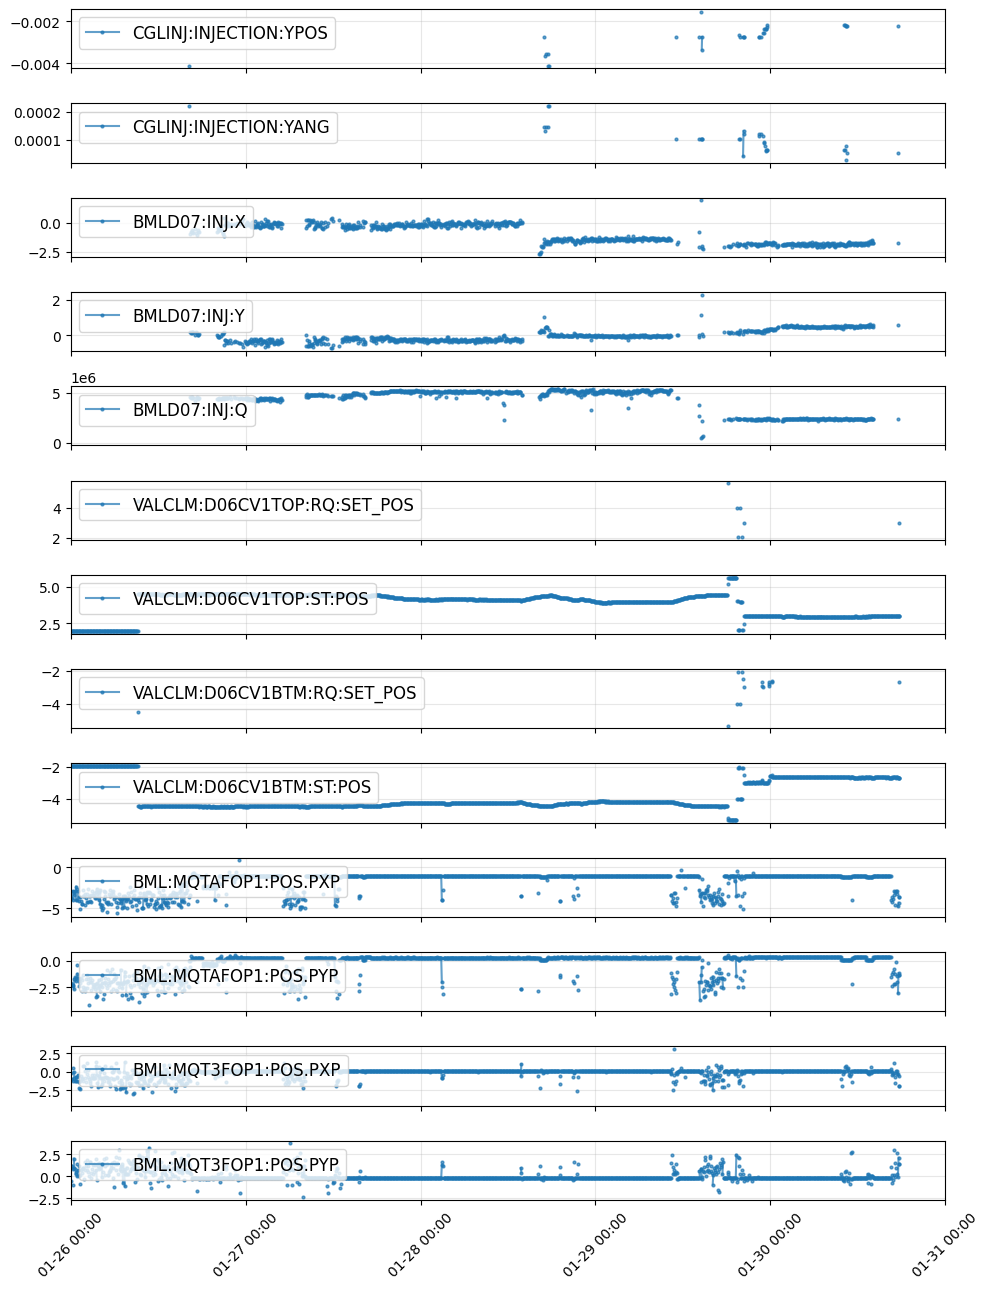

Saved acc_group1_14.png and acc_group2_13.png


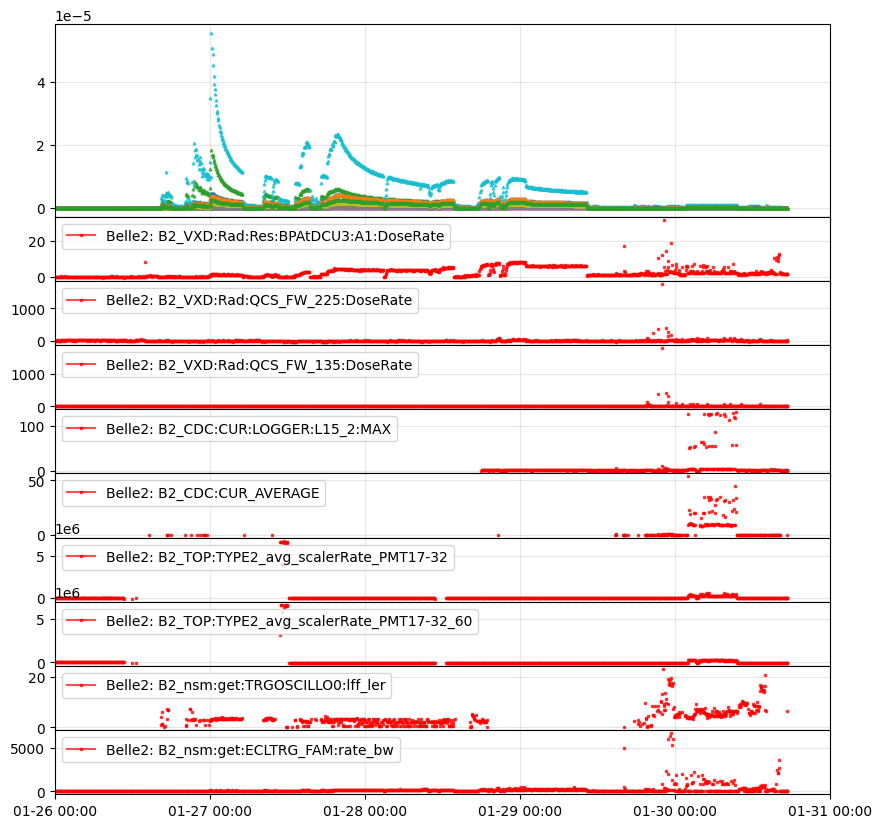

In [18]:
# Split combined ACC columns into two groups (14 and 13) and plot each with no vertical spacing
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

all_acc_cols = list(acc1_numeric_cols) + list(acc2_numeric_cols)
group1 = all_acc_cols[:14]
group2 = all_acc_cols[14:]

def plot_acc_group(cols, fname, figsize_width=10, height_per_trace=1, legend_fs=12, tick_fs=10):
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(figsize_width, height_per_trace * n), sharex=True)
    axes = np.atleast_1d(axes)
    for i, col in enumerate(cols):
        src_df = acc_df1 if col in acc_df1.columns else acc_df2
        axes[i].plot(src_df['Timestamp'], src_df[col], marker='o', markersize=2, alpha=0.7, linestyle='-',
                     label=f'{col}')
        axes[i].legend(loc='upper left', fontsize=legend_fs)
        axes[i].grid(True, alpha=0.3)
        if i < n - 1:
            axes[i].tick_params(labelbottom=False)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    for ax in axes:
        ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
    plt.xticks(rotation=45, fontsize=tick_fs)
    plt.subplots_adjust(hspace=0)   # remove vertical spacing
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_acc_group(group1, 'acc_group1.png', figsize_width=10, height_per_trace=1)
plot_acc_group(group2, 'acc_group2.png', figsize_width=10, height_per_trace=1)
print("Saved acc_group1_14.png and acc_group2_13.png")

# make vacuum subplot taller using height ratios (paste over your fig3/axes3 creation & vacuum+Belle2 plotting)
import numpy as np

total_subplots = 1 + len(belle2_numeric_cols)
height_ratios = [3] + [1] * len(belle2_numeric_cols)  # vacuum subplot 3x taller

fig3, axes3 = plt.subplots(
    total_subplots, 1,
    figsize=(10, 1*total_subplots),
    sharex=True,
    gridspec_kw={'height_ratios': height_ratios}
)
axes3 = np.atleast_1d(axes3)

# Vacuum on first subplot (all traces)
for col in vacuum_numeric_cols:
    axes3[0].plot(vacuum_df['Timestamp'], vacuum_df[col], marker='^', markersize=2, alpha=0.7, linestyle='-', label=f'Vacuum: {col}')
# axes3[0].legend(loc='upper left', fontsize=10)
axes3[0].grid(True, alpha=0.3)
axes3[0].tick_params(labelbottom=False)

# Belle2 on remaining subplots
for i, col in enumerate(belle2_numeric_cols):
    idx = i + 1
    axes3[idx].plot(belle2_df['Timestamp'], belle2_df[col], marker='s', markersize=2, alpha=0.7, linestyle='-', color='red', label=f'Belle2: {col}')
    # axes3[idx].set_ylabel('Value', fontsize=12)
    axes3[idx].legend(loc='upper left', fontsize=10)
    axes3[idx].grid(True, alpha=0.3)
    if idx < len(axes3) - 1:
        axes3[idx].tick_params(labelbottom=False)

axes3[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
for ax in axes3:
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))

plt.subplots_adjust(hspace=0)
plt.savefig('belle2_plots.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# Build event-aligned data (next numeric value after event) + photocurrent
events = [
    {"time": "20260128_025331", "photocurrent_mA": 2.2626},
    {"time": "20260128_190150", "photocurrent_mA": 2.8673},
    {"time": "20260128_205419", "photocurrent_mA": 1.7922},
    {"time": "20260128_212802", "photocurrent_mA": 2.3857},
    {"time": "20260129_101918", "photocurrent_mA": 3.0952},
]

def parse_event_time(time_str):
    date_str, time_part = time_str.split('_')[0], time_str.split('_')[1]
    return pd.to_datetime(f"{date_str} {time_part}", format="%Y%m%d %H%M%S")

def next_value_after_event(df, ts, col, prefix):
    if df is None or df.empty or col not in df.columns:
        return {f"{prefix}_{col}": np.nan, f"{prefix}_{col}__Timestamp": pd.NaT, f"{prefix}_{col}__time_delta_s": np.nan}
    df_sorted = df.sort_values('Timestamp').reset_index(drop=True)
    mask = (df_sorted['Timestamp'] >= ts) & (df_sorted[col].notna())
    if not mask.any():
        return {f"{prefix}_{col}": np.nan, f"{prefix}_{col}__Timestamp": pd.NaT, f"{prefix}_{col}__time_delta_s": np.nan}
    row = df_sorted.loc[mask].iloc[0]
    return {
        f"{prefix}_{col}": row[col],
        f"{prefix}_{col}__Timestamp": row['Timestamp'],
        f"{prefix}_{col}__time_delta_s": (row['Timestamp'] - ts).total_seconds()
    }

event_records = []
for ev in events:
    event_time = parse_event_time(ev["time"])
    record = {
        "event_time": event_time,
        "event_time_str": ev["time"],
        "photocurrent_mA": ev["photocurrent_mA"]
    }
    # For every numeric column in each file, grab the next available non-NaN value after the event
    for col in acc1_numeric_cols:
        record.update(next_value_after_event(acc_df1, event_time, col, "acc1"))
    for col in acc2_numeric_cols:
        record.update(next_value_after_event(acc_df2, event_time, col, "acc2"))
    for col in belle2_numeric_cols:
        record.update(next_value_after_event(belle2_df, event_time, col, "belle2"))
    for col in vacuum_numeric_cols:
        record.update(next_value_after_event(vacuum_df, event_time, col, "vacuum"))
    event_records.append(record)

event_values_df = pd.DataFrame(event_records)
event_photocurrent_mA = event_values_df["photocurrent_mA"].values
event_times = event_values_df["event_time"].values

print("Event-aligned values (next non-NaN after event for every PV column):")
display(event_values_df[["event_time_str", "event_time", "photocurrent_mA"]])
print(f"Total variables per event (excluding metadata): {event_values_df.shape[1] - 3}")


Event-aligned values (next non-NaN after event for every PV column):


,event_time_str,event_time,photocurrent_mA
0,20260128_025331,2026-01-28 02:53:31,2.2626
1,20260128_190150,2026-01-28 19:01:50,2.8673
2,20260128_205419,2026-01-28 20:54:19,1.7922
3,20260128_212802,2026-01-28 21:28:02,2.3857
4,20260129_101918,2026-01-29 10:19:18,3.0952


Total variables per event (excluding metadata): 177


PV columns used for correlation: 59
(Using absolute values of all variables)


/Users/xylu/Desktop/Data/code/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/xylu/Desktop/Data/code/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,corr_with_photocurrent
acc1_BMLDCCT:CURRENT,0.599504
acc1_BTpBPM:QMD11P_K_1:NC_1Hz:C,0.565514
belle2_B2_VXD:Rad:Res:BPAtDCU3:A1:DoseRate,0.462352
acc1_CGLINJ:EFFICIENCY,0.437237
belle2_B2_TOP:TYPE2_avg_scalerRate_PMT17-32_60,0.435172
belle2_B2_TOP:TYPE2_avg_scalerRate_PMT17-32,0.432141
acc1_BMLD07:INJ:X,0.397961
belle2_B2_nsm:get:ECLTRG_FAM:rate_bw,0.261955
acc1_CGLINJ:SEPTUM:POS_R,0.236991
acc1_CGLINJ:KICKER:JUMP_R,0.236988


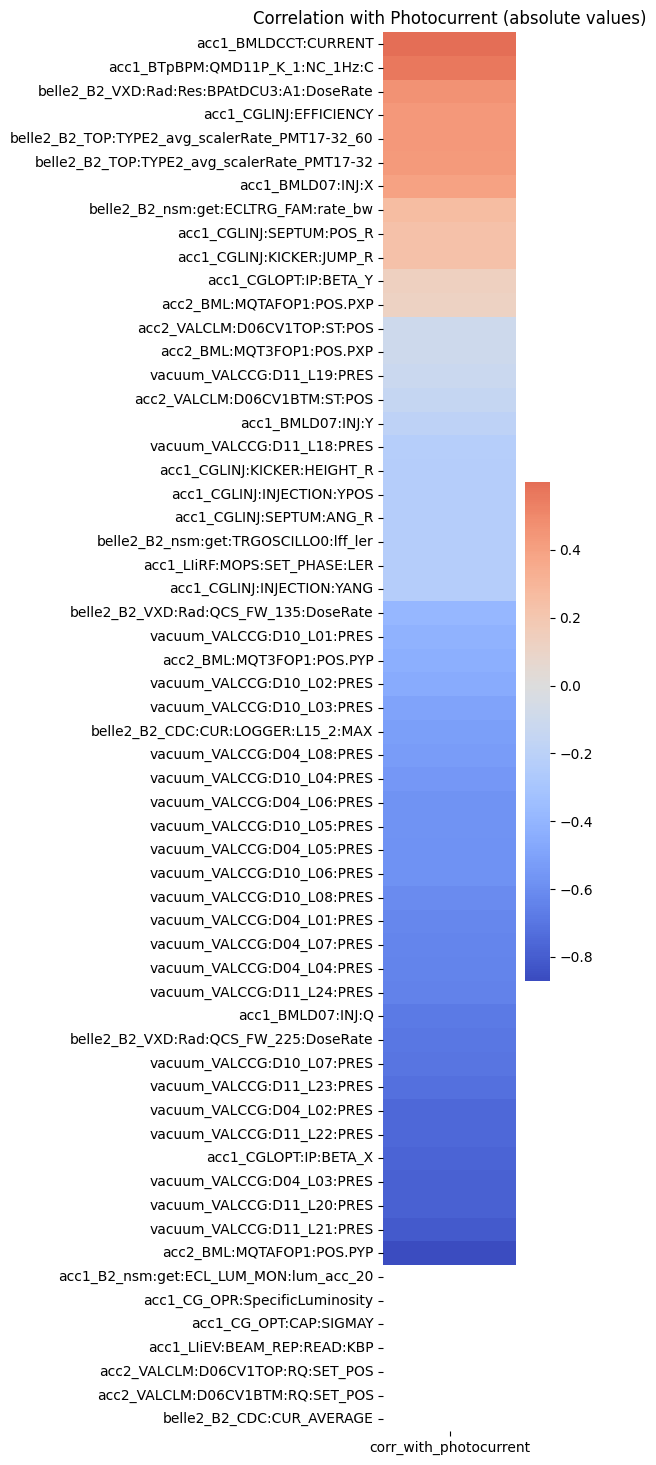

In [45]:
# Correlate all PV values with photocurrent + heatmap (using absolute values)
meta_cols = {"event_time", "event_time_str", "photocurrent_mA"}
exclude_suffixes = ("__Timestamp", "__time_delta_s")
pv_cols = [
    c for c in event_values_df.columns
    if c not in meta_cols and not c.endswith(exclude_suffixes)
    and pd.api.types.is_numeric_dtype(event_values_df[c])
 ]

# Create a copy with absolute values for correlation calculation
event_values_abs = event_values_df[pv_cols + ["photocurrent_mA"]].abs()

corr_series = event_values_abs[pv_cols].corrwith(event_values_abs["photocurrent_mA"])
corr_df = corr_series.to_frame(name="corr_with_photocurrent").sort_values(by="corr_with_photocurrent", ascending=False)

print(f"PV columns used for correlation: {len(pv_cols)}")
print("(Using absolute values of all variables)")
display(corr_df)

# Heatmap (single-column correlation view)
plt.figure(figsize=(6, max(6, len(corr_df) * 0.25)))
sns.heatmap(corr_df, cmap="coolwarm", center=0, cbar=True)
plt.title("Correlation with Photocurrent (absolute values)")
plt.tight_layout()
plt.show()


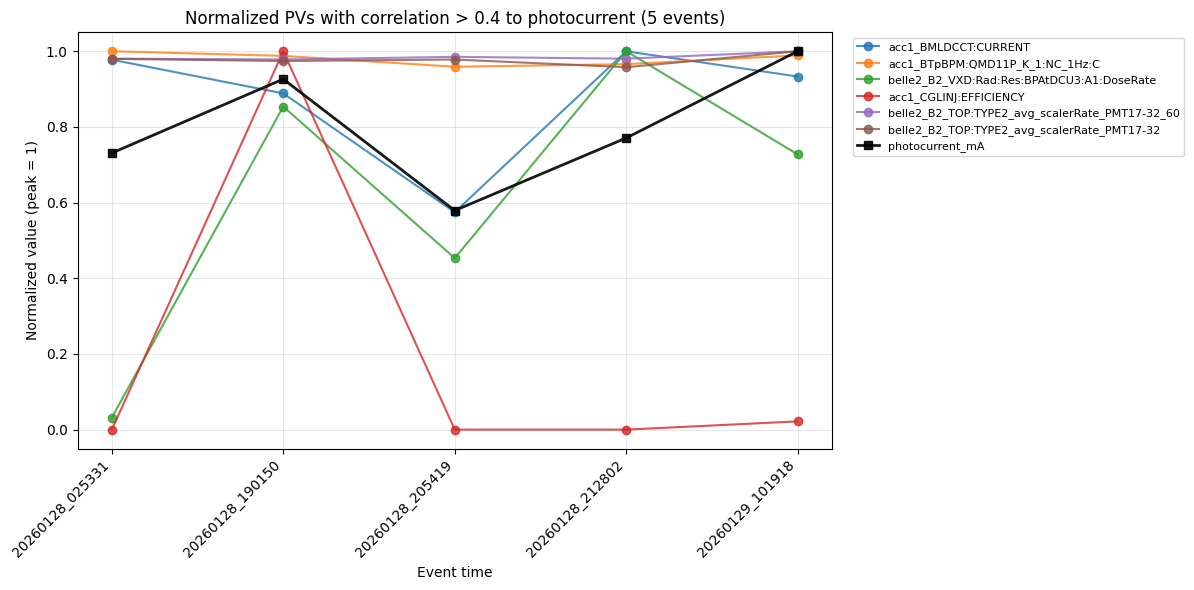

In [ ]:
# Plot PVs with strong correlation (>0.35) vs photocurrent (5 events) - normalized to peak
strong_corr_pv_cols = corr_df[corr_df["corr_with_photocurrent"] > 0.35].index.tolist()
if not strong_corr_pv_cols:
    print("No PV columns with correlation > 0.35.")
else:
    x_labels = event_values_df["event_time_str"].tolist()
    x = np.arange(len(x_labels))
    plt.figure(figsize=(12, 6))
    for col in strong_corr_pv_cols:
        y = np.abs(event_values_df[col].values.astype(float))  # Use absolute values
        y_peak = np.nanmax(y)
        if np.isfinite(y_peak) and y_peak != 0:
            y_norm = y / y_peak
        else:
            y_norm = np.full_like(y, np.nan, dtype=float)
        plt.plot(x, y_norm, marker='o', linewidth=1.5, alpha=0.8, label=col)
    # Photocurrent (normalized to peak) with different marker
    pc = np.abs(event_values_df["photocurrent_mA"].values.astype(float))  # Use absolute values
    pc_peak = np.nanmax(pc)
    if np.isfinite(pc_peak) and pc_peak != 0:
        pc_norm = pc / pc_peak
    else:
        pc_norm = np.full_like(pc, np.nan, dtype=float)
    plt.plot(x, pc_norm, marker='s', linewidth=2.0, alpha=0.9, color='black', label='photocurrent_mA')
    plt.xticks(x, x_labels, rotation=45, ha='right')
    plt.xlabel("Event time")
    plt.ylabel("Normalized value (peak = 1)")
    plt.title("Normalized PVs with correlation > 0.35 to photocurrent (5 events)")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


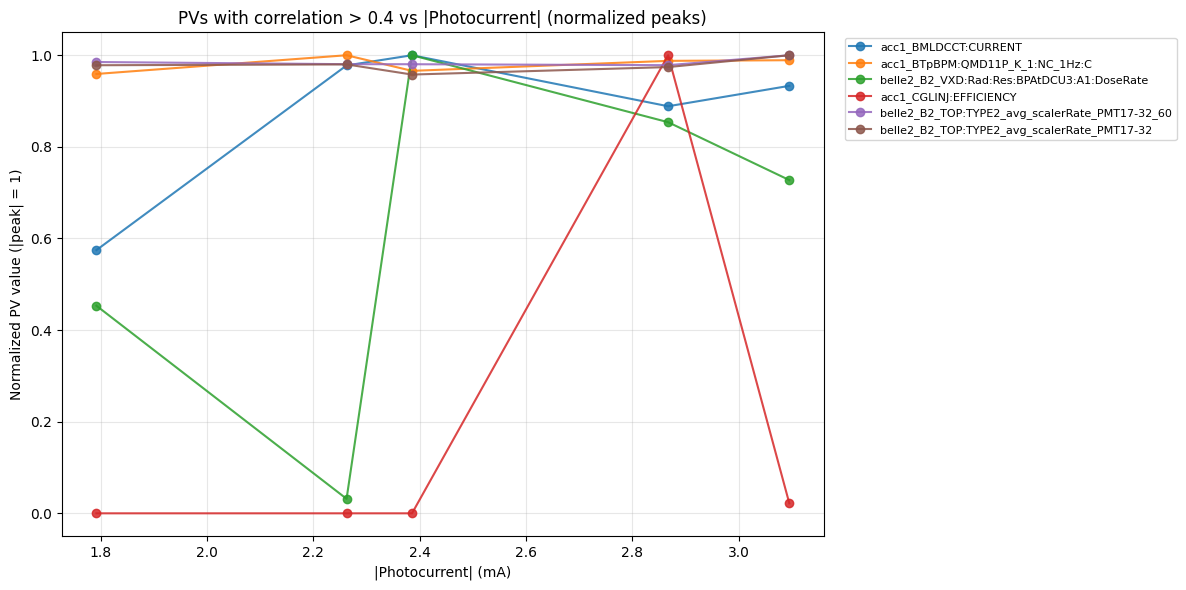

In [ ]:
# Plot PV values (corr > 0.35) vs photocurrent (x-axis) - normalized peaks
strong_corr_pv_cols = corr_df[corr_df["corr_with_photocurrent"] > 0.35].index.tolist()
if not strong_corr_pv_cols:
    print("No PV columns with correlation > 0.35.")
else:
    x = np.abs(event_values_df["photocurrent_mA"].values.astype(float))
    # Sort indices by photocurrent (small to large)
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]
    
    plt.figure(figsize=(12, 6))
    for col in strong_corr_pv_cols:
        y = np.abs(event_values_df[col].values.astype(float))  # Use absolute values
        y_peak = np.nanmax(y)
        if np.isfinite(y_peak) and y_peak != 0:
            y_norm = y / y_peak
        else:
            y_norm = np.full_like(y, np.nan, dtype=float)
        y_sorted = y_norm[sort_idx]
        plt.plot(x_sorted, y_sorted, marker='o', alpha=0.85, linewidth=1.5, label=col)
    plt.xlabel("|Photocurrent| (mA)")
    plt.ylabel("Normalized PV value (|peak| = 1)")
    plt.title("PVs with correlation > 0.35 vs |Photocurrent| (normalized peaks)")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()
